# Time Series Benchmarking Framework

Interactive notebook for running forecast horse-races.  
**Workflow:** Setup series → Configure knobs → Run benchmark → Inspect results

In [1]:
import os
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

In [2]:
from benchmark import (
    TimeSeries, SeriesRegistry,
    MeanForecaster, ARIMAForecaster, SSAForecaster, TimesFMForecaster,
    BenchmarkRunner, BenchmarkResults,
    ReplicatedBenchmarkRunner, ReplicatedBenchmarkResults,
)

In [3]:
spec = importlib.util.spec_from_file_location("local_secrets", "./secrets.py")
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
HF_token = mod.HF_token
os.environ["HF_TOKEN"] = HF_token

## 1. Setup Phase — Register Series

Load the default synthetic DGPs and (optionally) register your own.

In [4]:
SeriesRegistry.clear()
SeriesRegistry.register_defaults(n=600, seed=42)

print("Available series:", SeriesRegistry.list_available())

Available series: ['AR(2)', 'AR(5)', 'ARMA(2,2)', 'ARMA(5,5)', 'Seasonal(12)']


In [ ]:
# --- Register your own series (uncomment / adapt) ---

# From a CSV:
# SeriesRegistry.register_from_csv("SP500", path="data/sp500.csv", column="Close")
# SeriesRegistry.register_from_csv("FEDFUNDS", path="data/FEDFUNDS.csv", column="FEDFUNDS")
# SeriesRegistry.register_from_csv("GS10", path="data/GS10.csv", column="GS10")
# SeriesRegistry.register_from_csv("UNRATE", path="data/UNRATE.csv", column="UNRATE")

# From a raw array:
# my_values = np.random.randn(500).cumsum()
# SeriesRegistry.register("Random Walk", TimeSeries.from_array(my_values, name="Random Walk"))

print("Available series:", SeriesRegistry.list_available())

Available series: ['AR(2)', 'AR(5)', 'ARMA(2,2)', 'ARMA(5,5)', 'Seasonal(12)']


## 2. Benchmark Phase — Configure & Run

Use the widgets below to select a series, choose forecasters, and set parameters.

In [6]:
# ── Series selector ──────────────────────────────────────────────
series_dropdown = widgets.Dropdown(
    options=SeriesRegistry.list_available(),
    description='Series:',
    style={'description_width': 'initial'},
)

# ── Preview the selected series ──────────────────────────────────
preview_output = widgets.Output()

def _preview(change):
    with preview_output:
        clear_output(wait=True)
        ts = SeriesRegistry.get(series_dropdown.value)
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(ts.values, linewidth=0.8)
        ax.set_title(f"{ts.name}  (n={len(ts)})")
        ax.set_xlabel("t")
        plt.tight_layout()
        plt.show()

series_dropdown.observe(_preview, names='value')
_preview(None)

display(series_dropdown, preview_output)

Dropdown(description='Series:', options=('AR(2)', 'AR(5)', 'ARMA(2,2)', 'ARMA(5,5)', 'Seasonal(12)'), style=De…

Output()

In [7]:
# ── Forecaster & benchmark knobs ─────────────────────────────────

horizon_slider = widgets.IntSlider(
    value=1, min=1, max=30, step=1,
    description='Horizon (h):',
    style={'description_width': 'initial'},
)

k_first_slider = widgets.IntSlider(
    value=360, min=10, max=500, step=10,
    description='Training window (k_first):',
    style={'description_width': 'initial'},
)

# Forecaster toggles
use_mean = widgets.Checkbox(value=True, description='Mean (dumb baseline)')
mean_window = widgets.IntSlider(
    value=50, min=5, max=200, step=5,
    description='  Mean window:',
    style={'description_width': 'initial'},
)

use_arima = widgets.Checkbox(value=True, description='ARIMA')
arima_p = widgets.IntSlider(value=2, min=0, max=10, description='  ARIMA p:')
arima_d = widgets.IntSlider(value=0, min=0, max=2, description='  ARIMA d:')
arima_q = widgets.IntSlider(value=0, min=0, max=10, description='  ARIMA q:')

use_ssa = widgets.Checkbox(value=True, description='SSA')

use_timesfm = widgets.Checkbox(value=True, description='TimesFM 2.5')
tfm_context = widgets.IntSlider(
    value=512, min=64, max=1024, step=64,
    description='  TFM max_context:',
    style={'description_width': 'initial'},
)

display(
    widgets.HTML('<h4>Benchmark settings</h4>'),
    horizon_slider, k_first_slider,
    widgets.HTML('<h4>Forecasters</h4>'),
    use_mean, mean_window,
    use_arima, arima_p, arima_d, arima_q,
    use_ssa,
    use_timesfm, tfm_context,
)

HTML(value='<h4>Benchmark settings</h4>')

IntSlider(value=1, description='Horizon (h):', max=30, min=1, style=SliderStyle(description_width='initial'))

IntSlider(value=360, description='Training window (k_first):', max=500, min=10, step=10, style=SliderStyle(des…

HTML(value='<h4>Forecasters</h4>')

Checkbox(value=True, description='Mean (dumb baseline)')

...

IntSlider(value=0, description='  ARIMA d:', max=2)

IntSlider(value=0, description='  ARIMA q:', max=10)

Checkbox(value=True, description='SSA')

Checkbox(value=True, description='TimesFM 2.5')

IntSlider(value=512, description='  TFM max_context:', max=1024, min=64, step=64, style=SliderStyle(descriptio…

In [8]:
# ── Run button ───────────────────────────────────────────────────
import traceback

run_output = widgets.Output()
run_button = widgets.Button(description='Run Benchmark', button_style='success')

results: BenchmarkResults | None = None


def _on_run(btn):
    global results
    with run_output:
        clear_output(wait=True)
        try:
            ts = SeriesRegistry.get(series_dropdown.value)

            forecasters = []
            if use_mean.value:
                forecasters.append(MeanForecaster(window=mean_window.value))
            if use_arima.value:
                forecasters.append(
                    ARIMAForecaster(order=(arima_p.value, arima_d.value, arima_q.value))
                )
            if use_ssa.value:
                forecasters.append(SSAForecaster())
            if use_timesfm.value:
                forecasters.append(
                    TimesFMForecaster(max_context=tfm_context.value)
                )

            if not forecasters:
                print('Select at least one forecaster.')
                return

            runner = BenchmarkRunner(
                series=ts,
                forecasters=forecasters,
                k_first=k_first_slider.value,
                horizon=horizon_slider.value,
                verbose=True,
            )
            print(
                f'Running benchmark on "{ts.name}" '
                f'(n={len(ts)}, k_first={k_first_slider.value}, h={horizon_slider.value})...'
            )
            results = runner.run()
            print('\n── Summary ──')
            display(results.summary())
            print('\n── Diebold-Mariano (SE loss) ──')
            display(results.diebold_mariano())
        except Exception:
            print('Benchmark failed — full traceback:\n')
            traceback.print_exc()


# Re-running this cell won't stack duplicate click handlers
run_button.on_click(_on_run, remove=True)
run_button.on_click(_on_run)
display(run_button, run_output)

Button(button_style='success', description='Run Benchmark', style=ButtonStyle())

Output()

## 3. Results — Plots

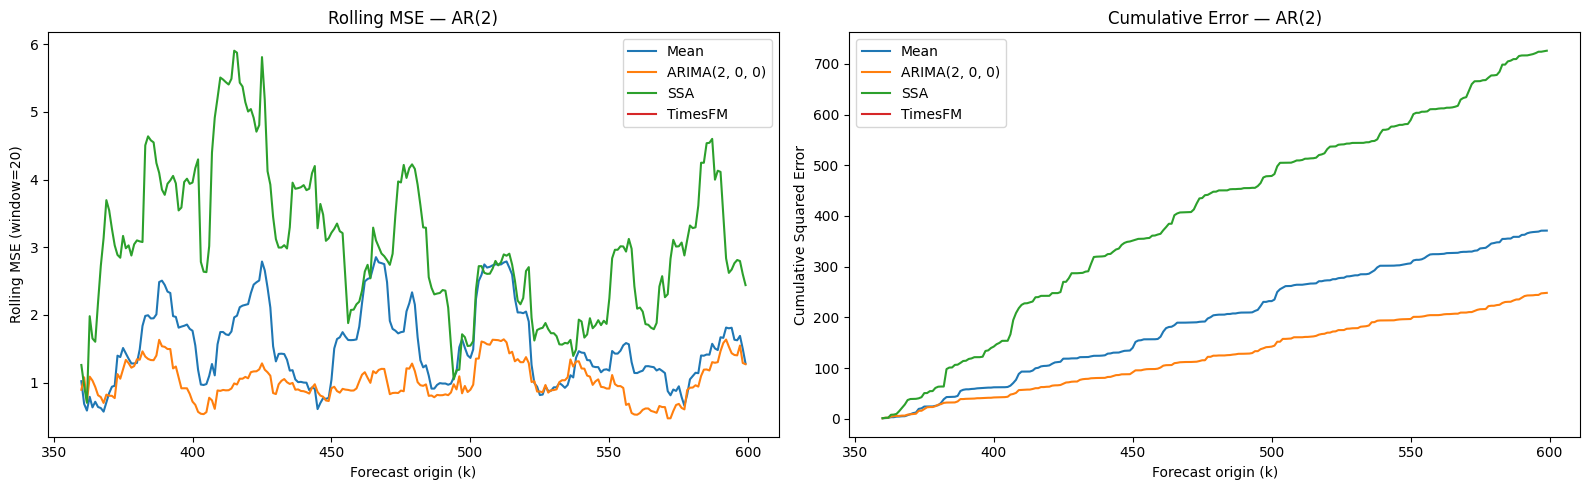

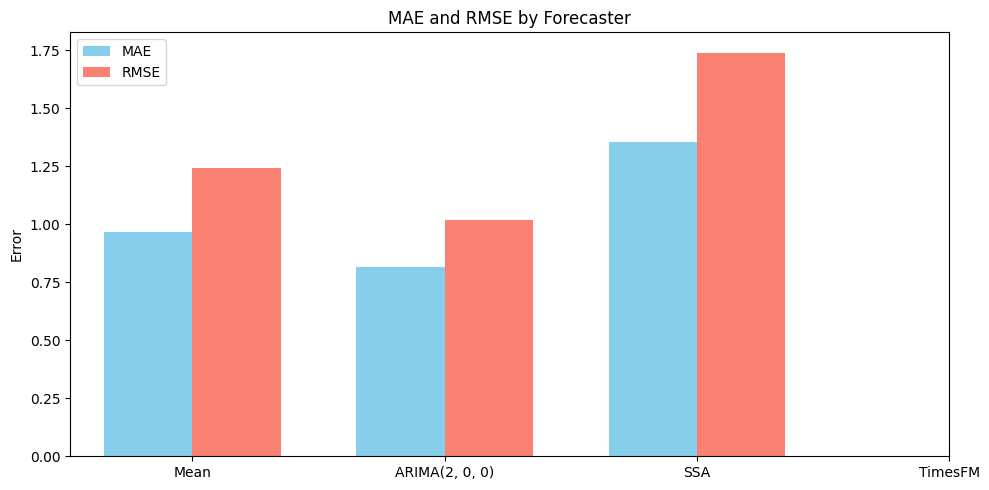

In [13]:
if results is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    results.plot_mse_over_time(rolling_window=20, ax=axes[0])
    results.plot_cumulative_error(ax=axes[1])
    plt.tight_layout()
    plt.show()

    # Bar chart for MAE and RMSE
    summary_df = results.summary()
    fig, ax = plt.subplots(figsize=(10, 5))
    forecasters = summary_df['Forecaster']
    mae = summary_df['MAE']
    rmse = summary_df['RMSE']
    x = np.arange(len(forecasters))
    width = 0.35
    ax.bar(x - width/2, mae, width, label='MAE', color='skyblue')
    ax.bar(x + width/2, rmse, width, label='RMSE', color='salmon')
    ax.set_xticks(x)
    ax.set_xticklabels(forecasters)
    ax.set_ylabel('Error')
    ax.set_title('MAE and RMSE by Forecaster')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Run the benchmark first (cell above).')

In [10]:
# ── Export results to CSV ────────────────────────────────────────
# if results is not None:
#     results.to_csv("benchmark_output.csv")
#     print("Saved to benchmark_output.csv")

## 4. Monte Carlo Replications — Same DGP, Multiple Seeds

Run the *same* DGP with many different random seeds so each replication
draws new AR/MA coefficients **and** new innovations.  This lets you
compare forecasters on the *distribution* of performance rather than a
single lucky/unlucky draw.

In [10]:
# ── DGP and replication settings ────────────────────────────────

dgp_options = {
    "AR(2)":       lambda seed: TimeSeries.from_ar(p=2, n=600, seed=seed),
    "AR(5)":       lambda seed: TimeSeries.from_ar(p=5, n=600, seed=seed),
    "ARMA(2,2)":   lambda seed: TimeSeries.from_arma(p=2, q=2, n=600, seed=seed),
    "ARMA(5,5)":   lambda seed: TimeSeries.from_arma(p=5, q=5, n=600, seed=seed),
    "Seasonal(12)": lambda seed: TimeSeries.from_seasonal(n=600, period=12, seed=seed),
}

mc_dgp_dropdown = widgets.Dropdown(
    options=list(dgp_options.keys()),
    description='DGP:',
    style={'description_width': 'initial'},
)

mc_n_replications = widgets.IntSlider(
    value=10, min=2, max=50, step=1,
    description='Replications:',
    style={'description_width': 'initial'},
)

mc_base_seed = widgets.IntSlider(
    value=0, min=0, max=1000, step=1,
    description='Base seed:',
    style={'description_width': 'initial'},
)

mc_horizon = widgets.IntSlider(
    value=1, min=1, max=30, step=1,
    description='Horizon (h):',
    style={'description_width': 'initial'},
)

mc_k_first = widgets.IntSlider(
    value=360, min=10, max=500, step=10,
    description='Training window (k_first):',
    style={'description_width': 'initial'},
)

# Forecaster toggles (reuse same settings as single-run section)
mc_use_mean = widgets.Checkbox(value=True, description='Mean (baseline)')
mc_use_arima = widgets.Checkbox(value=True, description='ARIMA')
mc_use_ssa = widgets.Checkbox(value=True, description='SSA')
mc_use_timesfm = widgets.Checkbox(value=True, description='TimesFM 2.5')

display(
    widgets.HTML('<h4>Monte Carlo settings</h4>'),
    mc_dgp_dropdown, mc_n_replications, mc_base_seed,
    mc_horizon, mc_k_first,
    widgets.HTML('<h4>Forecasters</h4>'),
    mc_use_mean, mc_use_arima, mc_use_ssa, mc_use_timesfm,
)

HTML(value='<h4>Monte Carlo settings</h4>')

Dropdown(description='DGP:', options=('AR(2)', 'AR(5)', 'ARMA(2,2)', 'ARMA(5,5)', 'Seasonal(12)'), style=Descr…

IntSlider(value=10, description='Replications:', max=50, min=2, style=SliderStyle(description_width='initial')…

IntSlider(value=0, description='Base seed:', max=1000, style=SliderStyle(description_width='initial'))

IntSlider(value=1, description='Horizon (h):', max=30, min=1, style=SliderStyle(description_width='initial'))

...

HTML(value='<h4>Forecasters</h4>')

Checkbox(value=True, description='Mean (baseline)')

Checkbox(value=True, description='ARIMA')

Checkbox(value=True, description='SSA')

Checkbox(value=True, description='TimesFM 2.5')

In [11]:
# ── Run Monte Carlo replications ────────────────────────────────

mc_output = widgets.Output()
mc_button = widgets.Button(description='Run Replications', button_style='success')

mc_results: ReplicatedBenchmarkResults | None = None

def _on_mc_run(btn):
    global mc_results
    with mc_output:
        clear_output(wait=True)

        forecasters = []
        if mc_use_mean.value:
            forecasters.append(MeanForecaster(window=50))
        if mc_use_arima.value:
            forecasters.append(ARIMAForecaster(order=(2, 0, 0)))
        if mc_use_ssa.value:
            forecasters.append(SSAForecaster())
        if mc_use_timesfm.value:
            forecasters.append(TimesFMForecaster(max_context=512))

        if not forecasters:
            print('Select at least one forecaster.')
            return

        dgp_factory = dgp_options[mc_dgp_dropdown.value]

        runner = ReplicatedBenchmarkRunner(
            dgp_factory=dgp_factory,
            forecasters=forecasters,
            n_replications=mc_n_replications.value,
            base_seed=mc_base_seed.value,
            k_first=mc_k_first.value,
            horizon=mc_horizon.value,
            verbose=True,
        )

        print(f'Running {mc_n_replications.value} replications of '
              f'"{mc_dgp_dropdown.value}" '
              f'(k_first={mc_k_first.value}, h={mc_horizon.value})...\n')
        mc_results = runner.run()

        print('\n── Aggregate Metrics (mean ± std across seeds) ──')
        display(mc_results.aggregate_metrics())
        print('\n── Pooled Diebold-Mariano (SE loss) ──')
        display(mc_results.pooled_diebold_mariano())

mc_button.on_click(_on_mc_run)
display(mc_button, mc_output)

Button(button_style='success', description='Run Replications', style=ButtonStyle())

Output()

### Monte Carlo Results — Plots

In [12]:
if mc_results is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    mc_results.plot_metric_distribution("mse", ax=axes[0])
    mc_results.plot_pooled_cumulative_error(ax=axes[1])
    plt.tight_layout()
    plt.show()

    # Per-seed breakdown
    print("\n── Per-seed MSE ──")
    display(mc_results.per_seed_metric("mse"))
else:
    print('Run the Monte Carlo replications first (cell above).')

Run the Monte Carlo replications first (cell above).
